# Trace Count v5.2: switch-token diagnostics

目标：解释为什么 mixed thinking-toggle Transformer 里，开关看起来学会了，但 targeted retrieval 不显著。

核心检查：

1. `<Think/>` / `</Think>` 的 switch logits 是否把 thinking 与 non-thinking 分开；
2. retrieval 是否测在正确的 **prediction query** 上，而不是 marker token 已经可见之后；
3. marker-only trace 是否因为缺少显式 `index_token_k`，天然不容易形成 v2 那种 k-to-k retrieval head。
            

## 1. Setup

## Google Drive Login

在实验开始时挂载一次 Google Drive。后面的保存 cell 会复用该挂载，因此长实验结束时不会再次弹出登录流程。

In [ ]:
from pathlib import Path
import sys

DRIVE_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/"
    "Synthetic_CoT_NiaH_Count/colab_results"
)
DRIVE_MOUNTED = False

def ensure_google_drive_mounted() -> bool:
    global DRIVE_MOUNTED
    if not ("google.colab" in sys.modules or Path("/content").exists()):
        print("Not in Colab; Google Drive mount skipped.")
        return False
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    DRIVE_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    DRIVE_MOUNTED = True
    print("Google Drive ready:", DRIVE_RESULTS_ROOT)
    return True

ensure_google_drive_mounted()

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()
INSTALL_DEPS = False
PULL_REPO = True

if IN_COLAB:
    repo_dir = Path("/content/Synthetic_CoT_NiaH_Count")
    cwd = Path.cwd()
    if (cwd / ".git").exists() or (cwd / "README.md").exists():
        repo_dir = cwd
    elif not repo_dir.exists():
        subprocess.run(["git", "clone", REPO_URL, str(repo_dir)], check=True)
    os.chdir(repo_dir)
    if PULL_REPO and (repo_dir / ".git").exists():
        subprocess.run(["git", "pull", "--ff-only"], check=False)

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if INSTALL_DEPS:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers>=4.40", "pandas", "matplotlib", "tqdm"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"], check=True)

import pandas as pd
from IPython.display import Markdown, display, Image

display(Markdown(f"**Repo root:** `{ROOT}`"))

**Repo root:** `/content/Synthetic_CoT_NiaH_Count`

## 2. Runtime settings

In [2]:
# A completed v5 checkpoint is required; v5.2 does not retrain the model.
# Set this only when you want to force a particular run or result bundle.
RUN_DIR_OVERRIDE = ""
AUTO_MOUNT_DRIVE_FOR_V5 = True
PREFER_DRIVE_V5 = True
DRIVE_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/"
    "Synthetic_CoT_NiaH_Count/colab_results"
)

from synthetic_counting_extensions.v5_2_switch_diagnostics import resolve_v5_run_dir


def find_v5_run() -> Path:
    if RUN_DIR_OVERRIDE:
        return resolve_v5_run_dir(RUN_DIR_OVERRIDE)

    local_search_roots = [
        Path("outputs/v5_explicit_switch"),
        Path("outputs/v5"),
        Path("outputs"),
        Path("runs"),
        Path("colab_results"),
    ]
    drive_search_roots = [DRIVE_RESULTS_ROOT / "v5", DRIVE_RESULTS_ROOT]

    if IN_COLAB and PREFER_DRIVE_V5 and AUTO_MOUNT_DRIVE_FOR_V5:
        if not Path("/content/drive/MyDrive").exists():
            from google.colab import drive

            ensure_google_drive_mounted()
        for root in drive_search_roots:
            try:
                return resolve_v5_run_dir(root)
            except FileNotFoundError:
                pass

    for root in local_search_roots:
        try:
            return resolve_v5_run_dir(root)
        except FileNotFoundError:
            pass

    if IN_COLAB and not PREFER_DRIVE_V5 and AUTO_MOUNT_DRIVE_FOR_V5:
        if not Path("/content/drive/MyDrive").exists():
            from google.colab import drive

            ensure_google_drive_mounted()
        for root in drive_search_roots:
            try:
                return resolve_v5_run_dir(root)
            except FileNotFoundError:
                pass

    searched = [str(path) for path in local_search_roots]
    if IN_COLAB:
        searched.append(str(DRIVE_RESULTS_ROOT))
    raise FileNotFoundError(
        "No completed v5 run was found. Run Trace_Count_v5_Colab first, or set "
        "RUN_DIR_OVERRIDE to a saved v5 result folder. Searched: " + ", ".join(searched)
    )


RUN_DIR = find_v5_run()

EXAMPLES_PER_COUNT = 100
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

print({
    "RUN_DIR": str(RUN_DIR),
    "CHECKPOINT": str(RUN_DIR / "checkpoints" / "final.pt"),
    "EXAMPLES_PER_COUNT": EXAMPLES_PER_COUNT,
    "DEVICE": DEVICE,
})
            

Mounted at /content/drive
{'RUN_DIR': '/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v5_synthetic_niah_v5/v5', 'CHECKPOINT': '/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v5_synthetic_niah_v5/v5/checkpoints/final.pt', 'EXAMPLES_PER_COUNT': 100, 'DEVICE': 'cuda'}


## 3. Run v5.2 diagnostics

In [3]:
from synthetic_counting_extensions.v5_2_switch_diagnostics import run_switch_and_retrieval_diagnostics

outputs = run_switch_and_retrieval_diagnostics(RUN_DIR, examples_per_count=EXAMPLES_PER_COUNT, device=DEVICE)
display(Markdown(f"**Report:** `{RUN_DIR / 'v5_2_switch_diagnostics' / 'report' / 'report.html'}`"))
display(outputs["switch_summary"])
display(outputs["prediction_query_head_summary"].sort_values(["correct_top1", "correct_prompt_needle_mass"], ascending=False).head(12))
            

[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (1) is identical to the `bos_token_id` (0), `eos_token_id` (1), or the `sep_token_id` (None), and your input is not padded.


**Report:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v5_synthetic_niah_v5/v5/v5_2_switch_diagnostics/report/report.html`

,variant,example_idx,count,p_close_after_think_open,p_any_marker_after_think_open,p_any_trace_start_after_think_open,p_any_count_after_think_close,p_gold_count_after_think_close,margin_close_vs_trace_start_after_open,margin_gold_count_vs_other_counts_after_close
0,nonthinking,499.5,5.5,1.732186e-08,1.0,1.0,1.0,1.0,-17.930726,18.069273
1,thinking,499.5,5.5,1.732186e-08,1.0,1.0,1.0,1.0,-17.930726,18.127784


,query_anchor,layer,head,query_kind,example_idx,count,k,target_marker_logit_margin_vs_markers,correct_top1,diag_share_of_needle_mass,correct_prompt_needle_mass,all_prompt_needles_mass,prompt_noise_mass,needle_entropy_normalized,bos_mass,think_open_mass,previous_trace_marker_mass,previous_trace_index_mass
6,prediction_query,2,2,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,1.000000,0.991831,0.991535,0.999704,0.000178,0.024076,0.000117,1.781417e-09,3.219212e-07,0.0
10,prediction_query,3,2,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.999455,0.974630,0.956078,0.980894,0.013545,0.050371,0.000401,5.032926e-04,1.277301e-04,0.0
4,prediction_query,2,0,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.991636,0.983897,0.983650,0.999754,0.000226,0.031843,0.000019,5.209770e-11,4.477813e-08,0.0
8,prediction_query,3,0,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.717636,0.664375,0.005186,0.006990,0.008823,0.170730,0.338800,8.679443e-04,8.587118e-03,0.0
9,prediction_query,3,1,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.562182,0.546883,0.541625,0.993980,0.004768,0.231234,0.000030,1.840548e-04,6.196700e-04,0.0
5,prediction_query,2,1,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.525273,0.519543,0.458870,0.908788,0.042521,0.355668,0.028106,7.355096e-04,8.946947e-04,0.0
15,prediction_query,4,3,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.327091,0.279903,0.079166,0.272750,0.694407,0.703820,0.002675,7.527179e-03,1.153422e-02,0.0
7,prediction_query,2,3,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.323091,0.361347,0.198339,0.554956,0.286464,0.637696,0.002277,1.984848e-02,4.692887e-02,0.0
13,prediction_query,4,1,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.294909,0.264275,0.007079,0.034715,0.868779,0.695871,0.002913,1.506176e-02,2.749704e-02,0.0
11,prediction_query,3,3,previous_token_predicts_marker_k,495.268545,7.0,4.0,16.848865,0.222182,0.263897,0.226023,0.950629,0.020178,0.156091,0.001616,2.818368e-03,1.022701e-02,0.0


## 4. Display figures

### switch_probability_summary.png

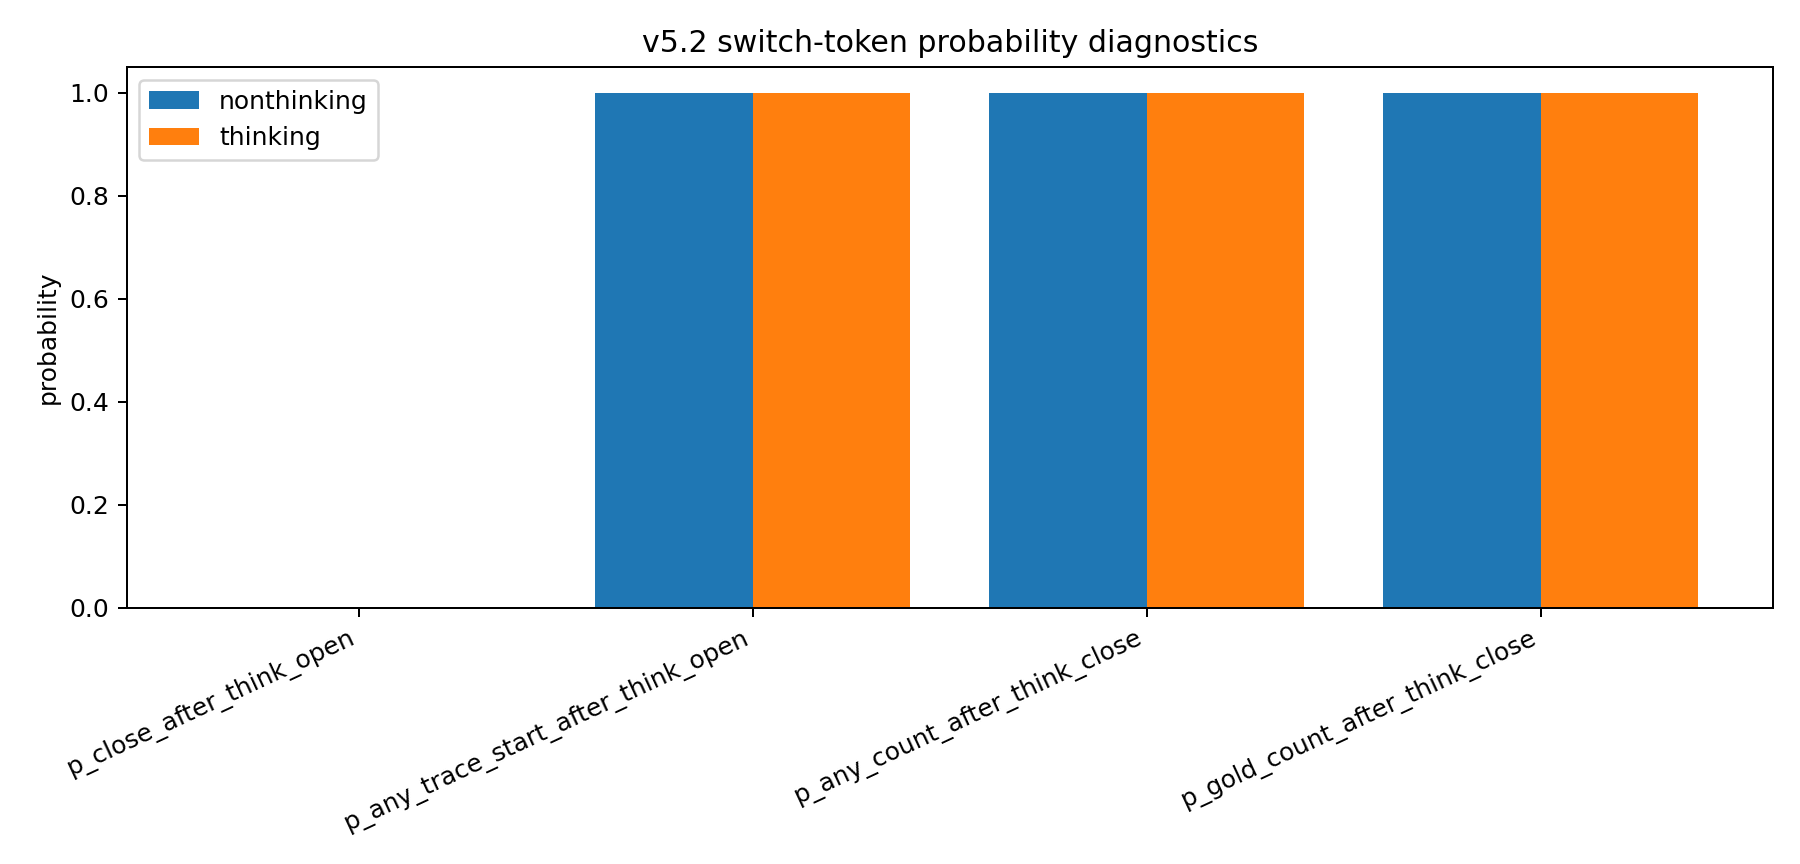

### prediction_query_correct_top1.png

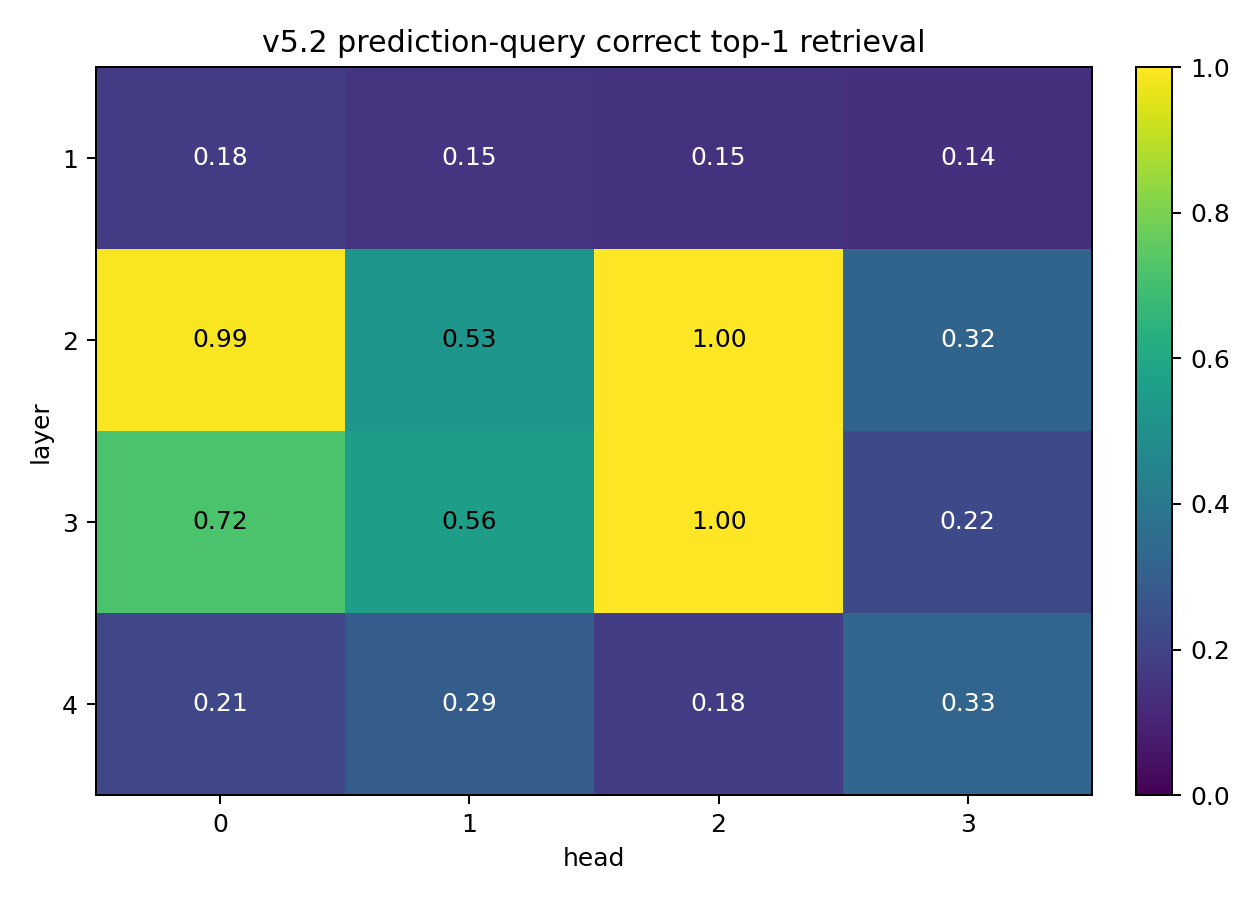

### prediction_query_correct_mass.png

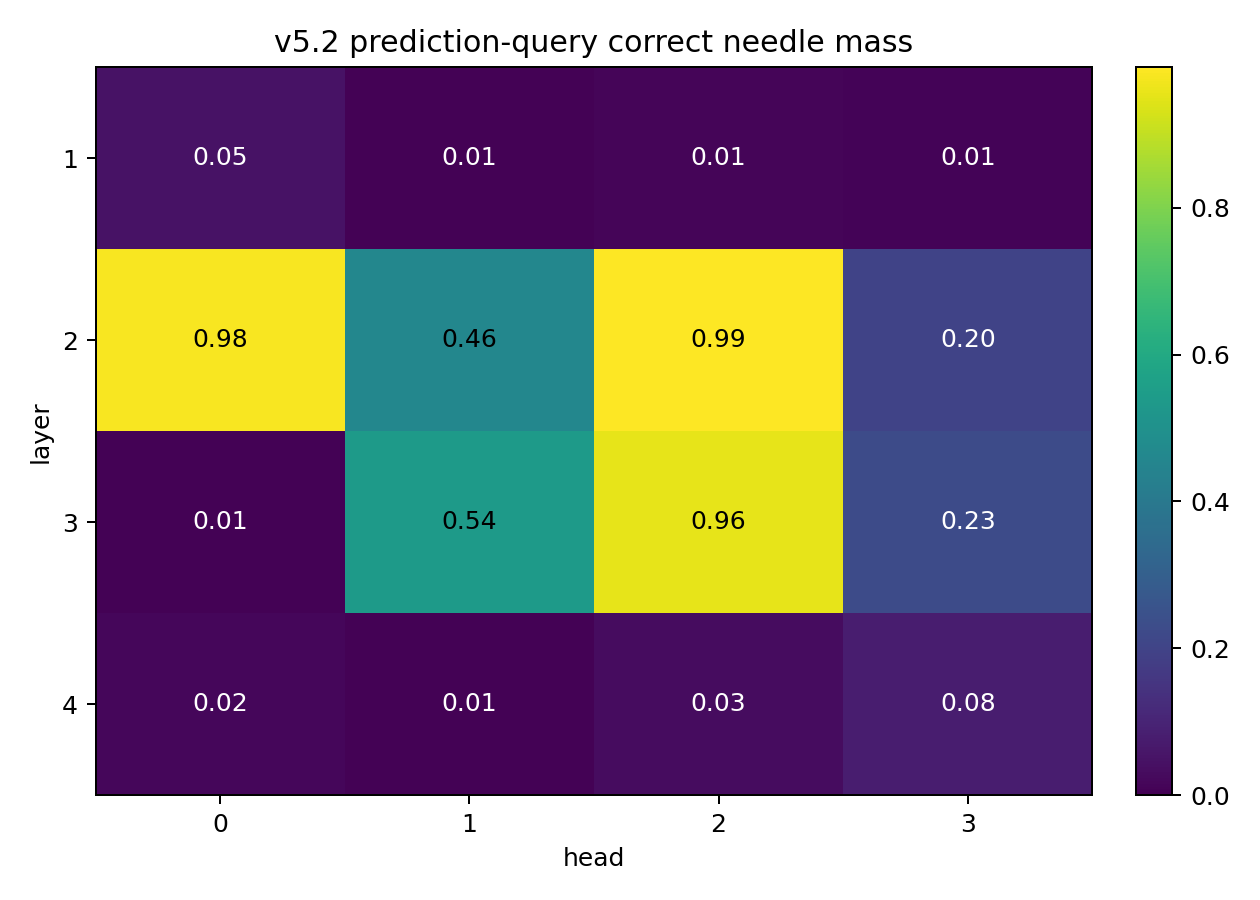

### prediction_query_marker_margin.png

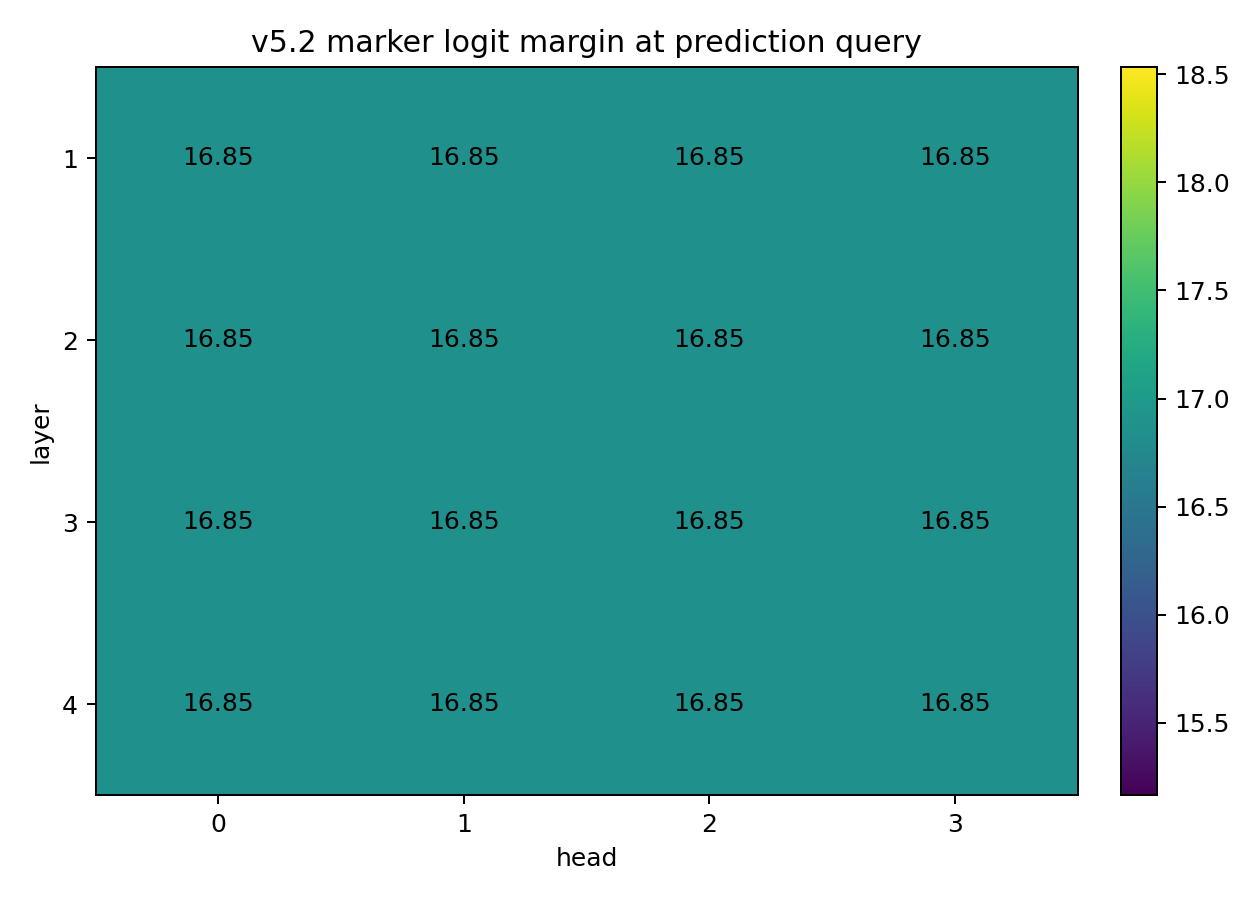

### post_marker_correct_top1.png

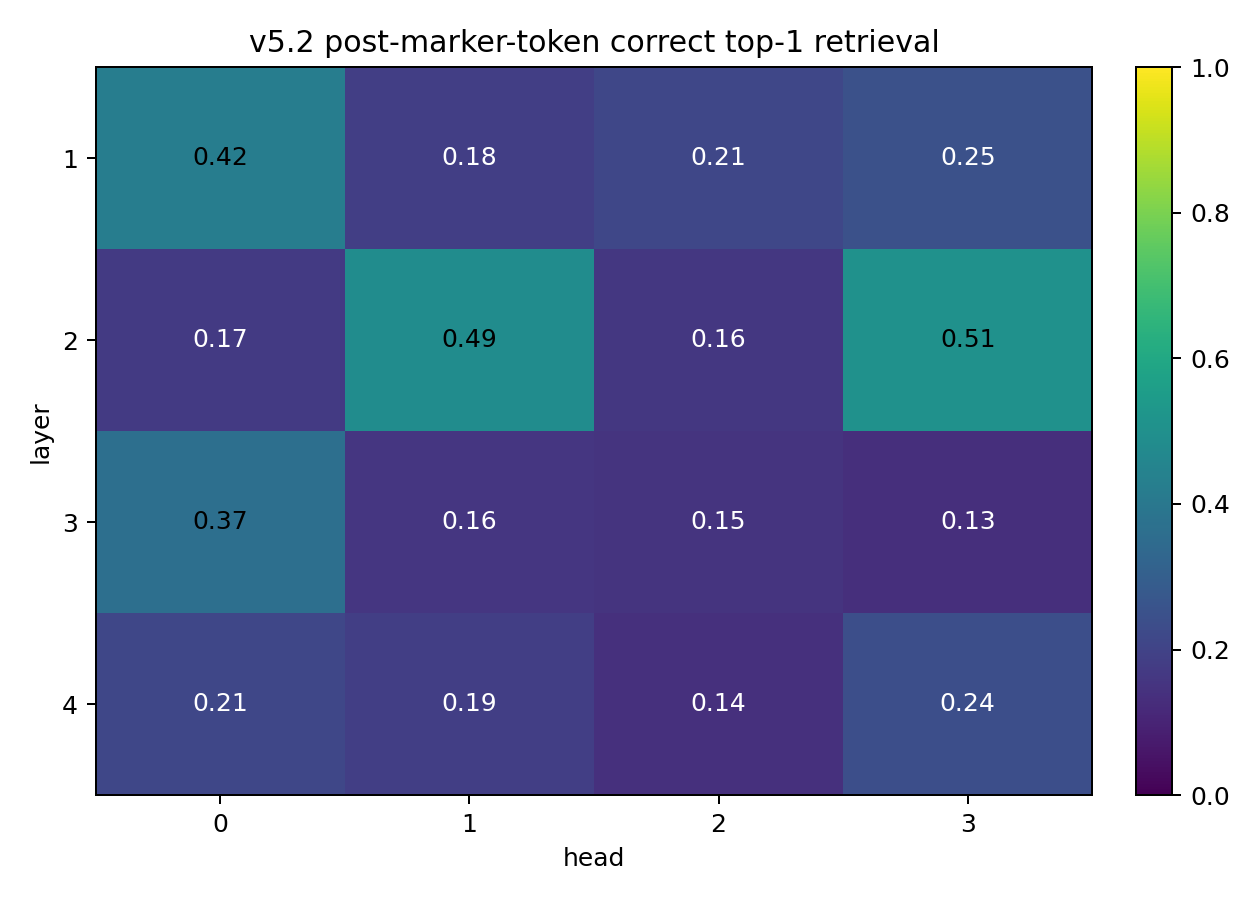

In [4]:
FIG_DIR = RUN_DIR / "v5_2_switch_diagnostics" / "figures"
for name in [
    "switch_probability_summary.png",
    "prediction_query_correct_top1.png",
    "prediction_query_correct_mass.png",
    "prediction_query_marker_margin.png",
    "post_marker_correct_top1.png",
]:
    path = FIG_DIR / name
    if path.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(path)))
            

## 5. Save / GitHub / disconnect

In [5]:
# Save result folder to Google Drive.
SAVE_TO_DRIVE = True
DRIVE_DEST_ROOT = "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results"

if SAVE_TO_DRIVE and IN_COLAB:
    from google.colab import drive
    ensure_google_drive_mounted()
    dest_root = Path(DRIVE_DEST_ROOT)
    dest_root.mkdir(parents=True, exist_ok=True)
    if "RUN_DIR" in globals() and RUN_DIR is not None:
        src = Path(RUN_DIR)
    elif "OUT_ROOT" in globals():
        src = Path(OUT_ROOT)
    else:
        src = None
    if src is not None and src.exists():
        dest = dest_root / src.name
        src_resolved = src.resolve()
        dest_root_resolved = dest_root.resolve()
        if src_resolved == dest_root_resolved or dest_root_resolved in src_resolved.parents:
            display(Markdown(f"**Already stored in Drive:** `{src}`"))
        else:
            if dest.exists():
                shutil.rmtree(dest)
            shutil.copytree(src, dest)
            display(Markdown(f"**Saved to Drive:** `{dest}`"))
    else:
        display(Markdown("No RUN_DIR/OUT_ROOT found to save."))
else:
    display(Markdown("Drive save skipped."))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Already stored in Drive:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v5_synthetic_niah_v5/v5`

In [6]:
# Optional: commit and push notebook/code changes to GitHub.
PUSH_TO_GITHUB = False
GIT_COMMIT_MESSAGE = "Add synthetic counting experiment notebook"

if PUSH_TO_GITHUB:
    subprocess.run(["git", "status", "--short"], check=False)
    subprocess.run(["git", "add", "notebooks", "src/synthetic_counting_extensions", "scripts"], check=True)
    subprocess.run(["git", "commit", "-m", GIT_COMMIT_MESSAGE], check=True)
    subprocess.run(["git", "push"], check=True)
else:
    display(Markdown("GitHub push skipped. Set `PUSH_TO_GITHUB = True` after checking the diff."))

GitHub push skipped. Set `PUSH_TO_GITHUB = True` after checking the diff.

In [8]:
# Optional: disconnect Colab runtime after saving.
AUTO_DISCONNECT_AFTER_SAVE = True

if AUTO_DISCONNECT_AFTER_SAVE and IN_COLAB:
    from google.colab import runtime
    runtime.unassign()
else:
    display(Markdown("Auto-disconnect skipped."))